In [15]:
import json
import os
import pandas as pd

analise_confusion_matrix = '../../6_analysis/analise_confusion_matrix.json'
analise_questions = '../../6_analysis/analise_questions.json'

with open(analise_confusion_matrix, 'r', encoding='utf-8') as f:
    confusion_matrix = json.load(f)

with open(analise_questions, 'r', encoding='utf-8') as f:
    questions = json.load(f)
    # transforme a lista de questões em um Dataframe do pandas
    questions_df = pd.DataFrame(questions)


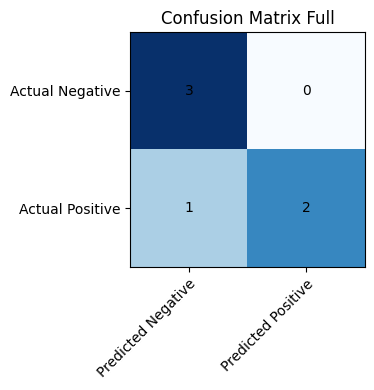

In [5]:
predicted_person = []
real_person = []
real_full = []
predicted_full = []

for index, question in enumerate(questions):
    if question['acerto_tutor_resp'] == 1:
        real_full.append(1)
    else:
        real_full.append(0)
    
    predicted_full.append(question['acerto_person_resp'])


# Gere uma matriz de confusão com base nos valores reais e previstos por persona existentes no dataset de questions.
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(real_full, predicted_full)
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(cm, cmap=plt.cm.Blues)
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Predicted Negative', 'Predicted Positive'])
ax.set_yticklabels(['Actual Negative', 'Actual Positive'])
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")
ax.set_title("Confusion Matrix Full")
fig.tight_layout()
plt.show()

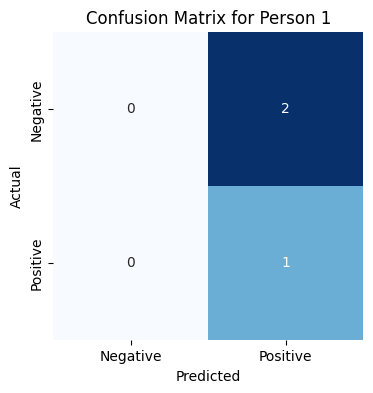

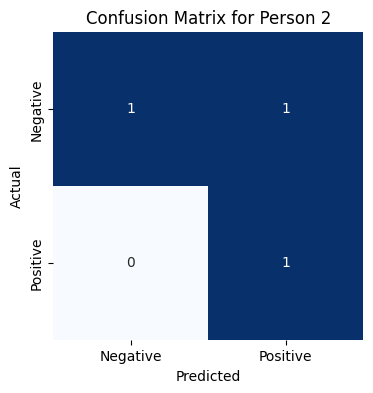

In [11]:
# Gere um gráfico de matrix de confusão que mostre a matriz por persona, ou seja, cada persona tem sua própria matriz de confusão.
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

for person_id, person_data in enumerate(confusion_matrix):
    cm_person = np.array([[person_data['true_negative'], person_data['false_positive']],
                          [person_data['false_negative'], person_data['true_positive']]])
    
    plt.figure(figsize=(4, 4))
    sns.heatmap(cm_person, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix for Person {person_id+1}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.xticks([0.5, 1.5], ['Negative', 'Positive'])
    plt.yticks([0.5, 1.5], ['Negative', 'Positive'])
    plt.show()


In [12]:
for index, person in enumerate(confusion_matrix):
    total = person['quantidade_questoes']

    # Accuracy = Acertos / Total de questões respondidas - Proporção de respostas corretas.
    acuracy = person['true_positive'] / total if total > 0 else 0
    print(f"Acuracy: {acuracy}")

    # Precision = Verdadeiros Positivos / (Verdadeiros Positivos + Falsos Positivos)
    precision = person['true_positive'] / (person['true_positive'] + person['false_positive']) if (person['true_positive'] + person['false_positive']) > 0 else 0
    print(f"Precision: {precision}")

    # Recall = Verdadeiros Positivos / (Verdadeiros Positivos + Falsos Negativos)
    recall = person['true_positive'] / (person['true_positive'] + person['false_negative']) if (person['true_positive'] + person['false_negative']) > 0 else 0
    print(f"Recall: {recall}")

Acuracy: 0.3333333333333333
Precision: 0.3333333333333333
Recall: 1.0
Acuracy: 0.3333333333333333
Precision: 0.5
Recall: 1.0


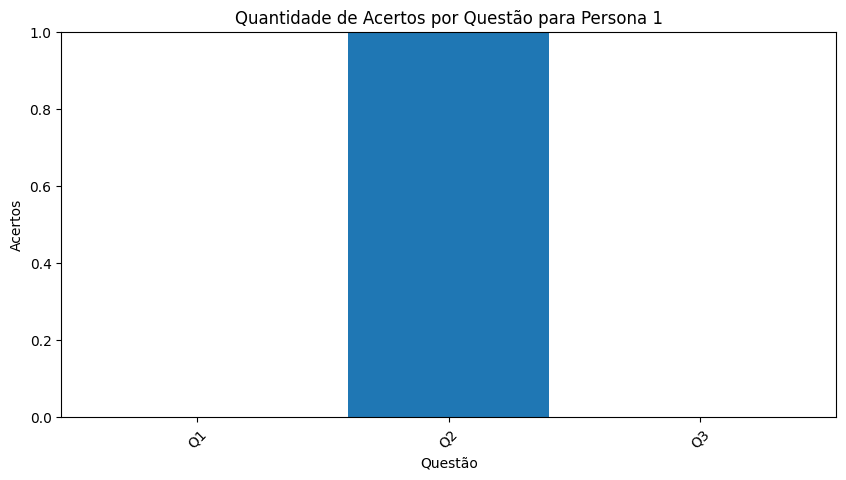

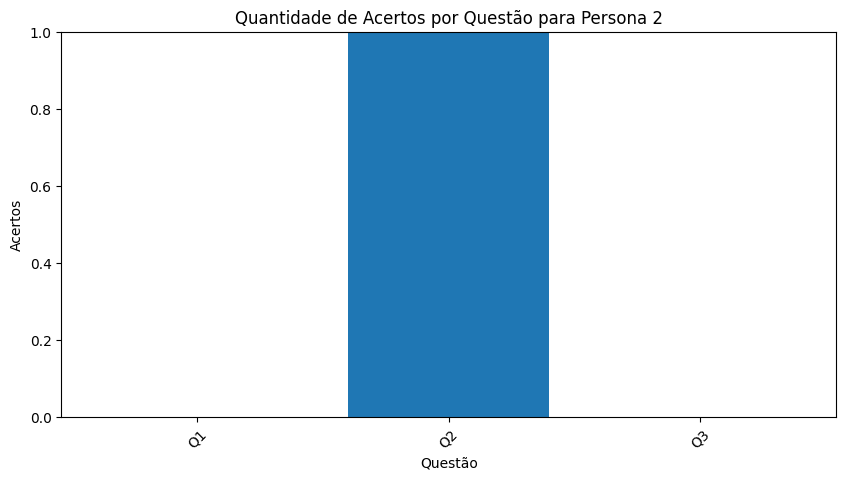

In [13]:
# Gere um gráfico de barras que mostre a quantidade de acertos e erros por persona e por questão, ou seja, cada barra representa uma questão e a altura da barra representa a quantidade de acertos da persona naquela questão.
# Utilize o dataset de questions para obter a quantidade de acertos e erros por persona e por questão.
import matplotlib.pyplot as plt

for person_id, person_data in enumerate(confusion_matrix):
    acertos = person_data['true_positive']
    erros = person_data['false_negative']
    
    plt.bar(['Acertos', 'Erros'], [acertos, erros], color=['green', 'red'])
    plt.title(f'Quantidade de Acertos e Erros para Persona {person_id+1}')
    plt.ylabel('Quantidade')
    plt.show()


In [16]:
# Gere um gráfico de barras que mostre a quantidade de acertos por questão, utilizando o dataframe de questões "questions_df".
# O modelo de dados do dataframe "questions_df" é o seguinte: 
# 
#  {
#     "person_id": 1,
#     "ano": 2024,
#     "area_descricao": "linguagens, códigos e suas tecnologias",
#     "area_sigla": "LC",
#     "questao_id": 22.0,
#     "gabarito": "C",
#     "param_a": 2.2483400000000002,
#     "param_b": 1.8179800000000002,
#     "param_c": 0.17832,
#     "resposta_person": "D",
#     "resposta_tutor": "C",
#     "acerto_person_resp": 0,
#     "acerto_tutor_resp": 0
#   }


questions_df.head()

,person_id,ano,area_descricao,area_sigla,questao_id,gabarito,param_a,param_b,param_c,resposta_person,resposta_tutor,acerto_person_resp,acerto_tutor_resp
0,1,2024,"linguagens, códigos e suas tecnologias",LC,22.0,C,2.24834,1.81798,0.17832,D,C,0,0
1,1,2024,"linguagens, códigos e suas tecnologias",LC,23.0,B,3.88590,0.87601,0.19923,B,C,1,1
2,1,2024,"linguagens, códigos e suas tecnologias",LC,24.0,D,1.94371,1.34885,0.14161,A,C,0,0
3,2,2024,"linguagens, códigos e suas tecnologias",LC,22.0,C,2.24834,1.81798,0.17832,D,C,0,0
4,2,2024,"linguagens, códigos e suas tecnologias",LC,23.0,B,3.88590,0.87601,0.19923,B,C,1,1


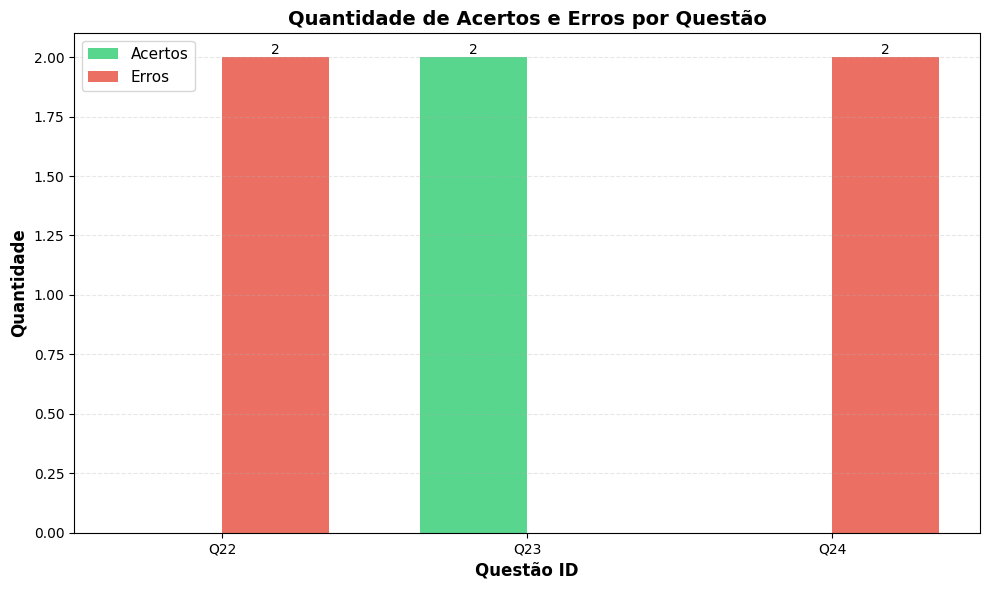


Resumo de Acertos e Erros por Questão:
Questão 22: 0 acertos, 2 erros (Taxa: 0.0%)
Questão 23: 2 acertos, 0 erros (Taxa: 100.0%)
Questão 24: 0 acertos, 2 erros (Taxa: 0.0%)


In [20]:
# Gere um gráfico de barras agrupadas que mostre a quantidade de acertos e erros por questão
import matplotlib.pyplot as plt
import numpy as np

# Agrupe os dados por questao_id e acerto_person_resp
acertos_por_questao = questions_df[questions_df['acerto_person_resp'] == 1].groupby('questao_id').size()
erros_por_questao = questions_df[questions_df['acerto_person_resp'] == 0].groupby('questao_id').size()

# Prepare os dados para o gráfico
questoes = sorted(questions_df['questao_id'].unique())
acertos = [acertos_por_questao.get(q, 0) for q in questoes]
erros = [erros_por_questao.get(q, 0) for q in questoes]

# Crie o gráfico de barras agrupadas
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(questoes))
width = 0.35

bars1 = ax.bar(x - width/2, acertos, width, label='Acertos', color='#2ecc71', alpha=0.8)
bars2 = ax.bar(x + width/2, erros, width, label='Erros', color='#e74c3c', alpha=0.8)

# Customize o gráfico
ax.set_xlabel('Questão ID', fontsize=12, fontweight='bold')
ax.set_ylabel('Quantidade', fontsize=12, fontweight='bold')
ax.set_title('Quantidade de Acertos e Erros por Questão', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'Q{int(q)}' for q in questoes])
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Adicione valores nas barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}',
                    ha='center', va='bottom', fontsize=10)

fig.tight_layout()
plt.show()

# Exiba o resumo dos dados
print("\nResumo de Acertos e Erros por Questão:")
print("=" * 50)
for q in questoes:
    acc = acertos_por_questao.get(q, 0)
    err = erros_por_questao.get(q, 0)
    total = acc + err
    taxa_acerto = (acc / total * 100) if total > 0 else 0
    print(f"Questão {int(q):2d}: {acc} acertos, {err} erros (Taxa: {taxa_acerto:.1f}%)")

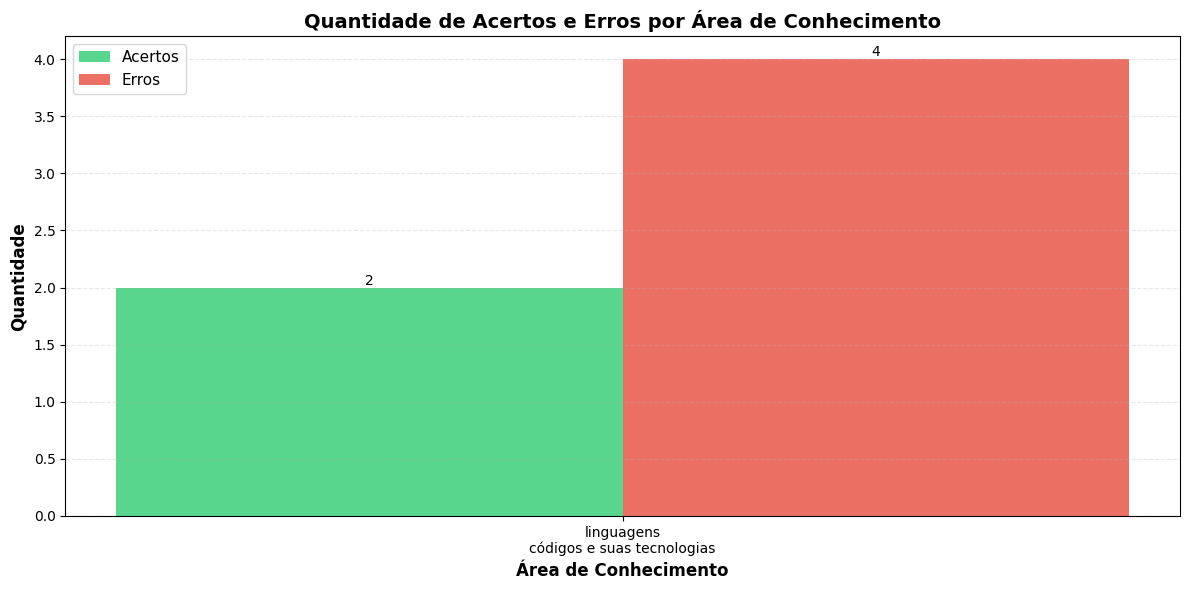


Resumo de Acertos e Erros por Área de Conhecimento:
linguagens, códigos e suas tecnologias       : 2 acertos, 4 erros (Taxa: 33.3%)


In [21]:
# Gere um gráfico de barras agrupadas que mostre a quantidade de acertos e erros por área de conhecimento
import matplotlib.pyplot as plt
import numpy as np

# Agrupe os dados por area_descricao e acerto_person_resp
acertos_por_area = questions_df[questions_df['acerto_person_resp'] == 1].groupby('area_descricao').size()
erros_por_area = questions_df[questions_df['acerto_person_resp'] == 0].groupby('area_descricao').size()

# Prepare os dados para o gráfico
areas = sorted(questions_df['area_descricao'].unique())
acertos = [acertos_por_area.get(area, 0) for area in areas]
erros = [erros_por_area.get(area, 0) for area in areas]

# Crie o gráfico de barras agrupadas
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(areas))
width = 0.35

bars1 = ax.bar(x - width/2, acertos, width, label='Acertos', color='#2ecc71', alpha=0.8)
bars2 = ax.bar(x + width/2, erros, width, label='Erros', color='#e74c3c', alpha=0.8)

# Customize o gráfico
ax.set_xlabel('Área de Conhecimento', fontsize=12, fontweight='bold')
ax.set_ylabel('Quantidade', fontsize=12, fontweight='bold')
ax.set_title('Quantidade de Acertos e Erros por Área de Conhecimento', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([area.replace(', ', '\n') for area in areas], fontsize=10)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Adicione valores nas barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}',
                    ha='center', va='bottom', fontsize=10)

fig.tight_layout()
plt.show()

# Exiba o resumo dos dados
print("\nResumo de Acertos e Erros por Área de Conhecimento:")
print("=" * 70)
for area in areas:
    acc = acertos_por_area.get(area, 0)
    err = erros_por_area.get(area, 0)
    total = acc + err
    taxa_acerto = (acc / total * 100) if total > 0 else 0
    print(f"{area:45s}: {acc} acertos, {err} erros (Taxa: {taxa_acerto:.1f}%)")